# TP MODELISATION DU CHURN

# Sommaire

1. [Import de la table préparée et Séparation Train / Test](#sect1)
2. [Standardisation des variables](#sect2)
3. [Modélisation](#sectmodel)
  - [Régression pénalisée](#sect41)
  - [Random Forest](#sect43)
  - [GBM (Gradient Boosting Machine)](#sect44)

In [1]:
import pandas as pd
import os
import numpy as np
import pickle
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score,roc_auc_score,roc_curve,auc

import matplotlib.pyplot as plt
import rich
from rich.pretty import pprint

# 1 Chargement des données préparées <a name="sect1" ></a>

In [2]:
repertoire = "../data"
os.chdir(repertoire)
file=open("churn_prepared.pydata","rb")
data=pickle.load(file)
file.close()

In [3]:
data.shape

(3333, 21)

In [4]:
data.describe()


,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?,churnMoy_state
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856,0.144914,0.145772
std,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491,0.352067,0.061771
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035714
25%,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000,0.000000,0.095238
50%,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000,0.000000,0.130435
75%,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000,0.000000,0.193548
max,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000,0.289474


In [5]:
data.dtypes

Account Length      int64
Int'l Plan           bool
VMail Plan           bool
VMail Message       int64
Day Mins          float64
Day Calls           int64
Day Charge        float64
Eve Mins          float64
Eve Calls           int64
Eve Charge        float64
Night Mins        float64
Night Calls         int64
Night Charge      float64
Intl Mins         float64
Intl Calls          int64
Intl Charge       float64
CustServ Calls      int64
Churn?              int64
Area Code_415        bool
Area Code_510        bool
churnMoy_state    float64
dtype: object

In [6]:
X = data.drop('Churn?',axis=1)
y =data['Churn?'].astype(int)

In [7]:
y.value_counts(normalize=True)

Churn?
0    0.855086
1    0.144914
Name: proportion, dtype: float64

In [8]:
# split Apprentissage Test
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, test_size=0.3,random_state=42)

In [9]:
X_train.shape, X_test.shape

((2333, 20), (1000, 20))

In [10]:
y_train.sum(), y_test.sum()

(np.int64(338), np.int64(145))

In [11]:
y_train.mean(), y_test.mean()

(np.float64(0.14487783969138449), np.float64(0.145))

# 2. Standardisation des variables <a name="sect2" ></a>

## Attention ici, on fit le scaler sur les données de train et on applique ce dernier à la fois sur les données de train et de test.
Il ne faut pas faut fit le scaler sur les données de test car cela serait considérer comme du leakage. ("data leakage" = utiliser,considérer, "regarder" les données de test pendant l'entrainement..)

In [12]:
from sklearn.preprocessing import StandardScaler
norm = StandardScaler().fit(X_train) 
X_train = pd.DataFrame(norm.transform(X_train), columns=X.columns)
X_test = pd.DataFrame(norm.transform(X_test), columns=X.columns)

In [13]:
X_train.describe()

,Account Length,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Area Code_415,Area Code_510,churnMoy_state
count,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03,2.333000e+03
mean,-1.614178e-16,3.350180e-17,3.350180e-17,8.527731e-17,-2.664916e-16,-2.215687e-16,-5.710534e-16,1.964424e-16,3.220741e-16,-3.136987e-16,-9.593697e-17,-7.614046e-18,7.279028e-16,-2.010108e-16,-9.136855e-17,3.959304e-16,-5.482113e-17,4.187725e-18,-2.131933e-17,-1.903511e-16
std,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00,1.000214e+00
min,-2.487259e+00,-3.186077e-01,-6.287567e-01,-6.014372e-01,-3.331687e+00,-5.004624e+00,-3.331755e+00,-3.942555e+00,-4.997841e+00,-3.942646e+00,-3.557234e+00,-3.436090e+00,-3.558946e+00,-3.601369e+00,-1.856517e+00,-3.601979e+00,-1.202826e+00,-1.006450e+00,-5.679457e-01,-1.784019e+00
25%,-6.634062e-01,-3.186077e-01,-6.287567e-01,-6.014372e-01,-6.710391e-01,-6.624940e-01,-6.705548e-01,-6.949818e-01,-6.613366e-01,-6.953804e-01,-6.760070e-01,-6.688108e-01,-6.742155e-01,-6.451014e-01,-6.183081e-01,-6.431349e-01,-4.329515e-01,-1.006450e+00,-5.679457e-01,-8.153774e-01
50%,-1.381472e-02,-3.186077e-01,-6.287567e-01,-6.014372e-01,-7.267824e-03,3.623950e-02,-7.435909e-03,1.952346e-02,-1.335321e-02,1.855747e-02,-7.867457e-03,-2.613915e-03,-9.880450e-03,2.357809e-02,-2.055720e-01,2.162742e-02,-4.329515e-01,9.935910e-01,-5.679457e-01,-2.426155e-01
75%,6.607610e-01,-3.186077e-01,1.590440e+00,8.570659e-01,6.713363e-01,6.850635e-01,6.709521e-01,6.576843e-01,6.844750e-01,6.587986e-01,6.662914e-01,6.635829e-01,6.678305e-01,6.570640e-01,6.199004e-01,6.603206e-01,3.369234e-01,9.935910e-01,-5.679457e-01,7.844434e-01
max,3.558938e+00,3.138656e+00,1.590440e+00,3.117746e+00,3.172530e+00,3.230450e+00,3.172917e+00,3.177049e+00,3.475788e+00,3.176005e+00,3.902655e+00,3.840829e+00,3.900333e+00,3.437363e+00,5.572734e+00,3.436681e+00,5.726047e+00,9.935910e-01,1.760732e+00,2.345453e+00


In [14]:
X_test.describe()

,Account Length,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Area Code_415,Area Code_510,churnMoy_state
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.042625,0.054777,-0.049546,-0.036048,0.005136,0.026906,0.005136,-0.027554,-0.025515,-0.027542,0.025407,0.009685,0.025508,0.005031,-0.025619,0.005100,0.001258,-0.044430,0.063126,0.023222
std,0.982330,1.073604,0.975114,0.993613,1.032593,1.005203,1.032595,0.975330,0.976362,0.975363,1.048096,1.009313,1.048094,0.940531,1.051659,0.940386,1.041961,0.999798,1.035559,1.017102
min,-2.487259,-0.318608,-0.628757,-0.601437,-3.331687,-5.004624,-3.331755,-3.000974,-2.854511,-3.000709,-3.145916,-3.179860,-3.144294,-3.601369,-1.856517,-3.601979,-1.202826,-1.006450,-0.567946,-1.784019
25%,-0.638422,-0.318608,-0.628757,-0.601437,-0.652498,-0.612584,-0.652832,-0.669534,-0.661337,-0.670047,-0.647415,-0.668811,-0.648578,-0.574714,-0.618308,-0.577962,-0.432951,-1.006450,-0.567946,-0.885824
50%,0.011170,-0.318608,-0.628757,-0.601437,0.012200,0.036240,0.012196,-0.033330,-0.013353,-0.034412,0.060351,-0.002614,0.061458,0.058772,-0.205572,0.060731,-0.432951,-1.006450,-0.567946,-0.120628
75%,0.685745,-0.318608,1.590440,0.565365,0.720470,0.685063,0.720850,0.679707,0.634630,0.680102,0.793699,0.714829,0.793787,0.657064,0.619900,0.660321,0.336923,0.993591,1.760732,0.810050
max,3.084237,3.138656,1.590440,3.044821,3.098366,3.130631,3.098752,3.139856,3.176719,3.139157,3.639814,3.277124,3.641733,2.733490,6.398207,2.732815,5.726047,0.993591,1.760732,2.345453


# 3. Modélisation <a name="sectmodel" ></a>

In [15]:
# Import de la fonction de lift à utiliser
os.chdir('../modules/')
from fonctions_metrics import lift

## 3.1 PARAMETRER LE MODELE REG PENALISEE <a name="sect41" ></a>
Choisir ridge (L2) ou lasso (L1) ou elasticnet, avec la classe LogisticRegression
Définir une grille d'hyper param pour C
et utliser GridSearchCV pour la balayer

Détails sur les paramètres de la GridSearchCV :
- cv=4 : le jeu d’entraînement est divisé en 4 parties (validation croisée). Chaque combinaison d’hyperparamètres est évaluée sur ces 4 folds.
- n_jobs=-1 : utilise tous les cœurs disponibles du processeur pour paralléliser les calculs, ce qui accélère fortement la recherche.
- refit=True : après la recherche, un nouvel estimateur est automatiquement réentraîné sur l’ensemble du jeu d’entraînement avec les meilleurs hyperparamètres trouvés. Ainsi, l’objet modeleLassoCV est directement exploitable (prédictions, score, etc.).
- scoring='roc_auc' : la métrique utilisée pour comparer les modèles est l’aire sous la courbe ROC (ROC AUC), adaptée aux problèmes de classification binaire déséquilibrée.


In [16]:
# Plus C est petit plus la pénalisation est forte et plus le modèle a tendance à mettre des poids à 0 
param = [{"C":[0.001,0.005,0.01,0.025,0.05,0.075,0.1]}]
# Instancie le modele LASSO : construction classe
lr=LogisticRegression(penalty='l1',solver='liblinear', class_weight="balanced")
# Grid Search : on indique le modele et la grille de param
modeleLassoCV = GridSearchCV (lr,param,cv = 4,n_jobs=-1,scoring='roc_auc', refit=True)


modeleLassoCV = modeleLassoCV.fit(X_train,y_train)
print(modeleLassoCV.best_params_)
print(modeleLassoCV.best_score_)

/home/user/python-formation-3/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/user/python-formation-3/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/user/python-formation-3/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead

{'C': 0.05}
0.8253290447453578


/home/user/python-formation-3/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/user/python-formation-3/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [17]:
modeleLassoCV.best_params_['C']

0.05

In [18]:
pd.DataFrame(modeleLassoCV.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
4,0.147983,0.025627,0.023136,0.005636,0.050,{'C': 0.05},0.808157,0.821572,0.834001,0.837586,0.825329,0.011559,1
5,0.427311,0.402834,0.017562,0.010228,0.075,{'C': 0.075},0.808417,0.822526,0.832451,0.836570,0.824991,0.010845,2
6,0.168025,0.097834,0.018996,0.004996,0.100,{'C': 0.1},0.808818,0.822955,0.831854,0.835719,0.824837,0.010342,3
3,0.076015,0.024945,0.020761,0.002647,0.025,{'C': 0.025},0.805305,0.816848,0.835791,0.838105,0.824012,0.013589,4
2,0.042973,0.018634,0.031591,0.014942,0.010,{'C': 0.01},0.781351,0.798764,0.829802,0.818167,0.807021,0.018509,5
1,0.024741,0.018714,0.018912,0.018976,0.005,{'C': 0.005},0.779925,0.768656,0.816407,0.741094,0.776520,0.027016,6
0,0.044233,0.012878,0.031199,0.014216,0.001,{'C': 0.001},0.500000,0.500000,0.500000,0.500000,0.500000,0.000000,7


In [19]:
# Visualisation des coefficients estimées pour chaque variable
coef=list(modeleLassoCV.best_estimator_.coef_[0])
coef_df = pd.DataFrame({'Coefficients': list(coef)}, list(X_train.columns.values))
coef_df.sort_values(['Coefficients'], ascending=False)

,Coefficients
CustServ Calls,0.668396
Int'l Plan,0.606551
Day Charge,0.325375
churnMoy_state,0.310273
Eve Mins,0.233557
Day Mins,0.220238
Intl Charge,0.135523
Night Charge,0.060606
Eve Calls,0.036912
Account Length,0.027719


In [20]:
# combien d'élemnts non nuls ?
feature_0= [i for i in coef if i==0] #print(feature_0)
print(len(feature_0))
# PLus on baisse C, plus de colonnes s'annulent (0)

4


### Analyser les résultats et les performances 

In [21]:
# Prediction des probabilités de 1 avec 
# Colonne 1 signifie la seconde modalité du vecteur soit la proba Churn=1
probas_test = modeleLassoCV.predict_proba(X_test)[:,1]
probas_train = modeleLassoCV.predict_proba(X_train)[:,1]

In [22]:
# score: accuracy taux de bien classé global au cutoff de 0.5
print(modeleLassoCV.score(X_test, y_test))
print(modeleLassoCV.score(X_train,y_train))

0.8229239766081871
0.8317331791016002


In [23]:
#AUC
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))

0.8317331791016002
0.8229239766081871


In [24]:
print(lift(probas_train,X_train,y_train))
print(lift(probas_test,X_test,y_test))

# Le lift à 10% : je prend les 10% plus fortes proba de churn (individus les plus risqués),
# taux de churn / taux de churn moyen 

lift at 10 percent : 3.58
3.58
lift at 10 percent : 3.86
3.86


In [25]:
#compute lift at 5%
print(lift(probas_train,X_train,y_train,p=5))
print(lift(probas_test,X_test,y_test,p=5))

lift at 5 percent : 3.91
3.91
lift at 5 percent : 4.28
4.28


In [26]:
# ENR LES RESULTATS DANS UN DICTIONNAIRE POUR POUVOIR COMPARER
model='Score Lasso'
# métriques (liste de dictionnaires)
metriques = [{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}]
metriques

lift at 5 percent : 4.28
lift at 10 percent : 3.86


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)}]

In [27]:
# mat de confusion à un cutoff donné
target_names = ['Fidèles','Churners']

# métriques au cutoff donné
print(classification_report(y_train,modeleLassoCV.predict(X_train), target_names=target_names))
# métriques au cutoff par défaut
print(classification_report(y_test,modeleLassoCV.predict(X_test), target_names=target_names))



              precision    recall  f1-score   support

     Fidèles       0.96      0.76      0.85      1995
    Churners       0.36      0.79      0.50       338

    accuracy                           0.77      2333
   macro avg       0.66      0.78      0.67      2333
weighted avg       0.87      0.77      0.80      2333

              precision    recall  f1-score   support

     Fidèles       0.95      0.76      0.84       855
    Churners       0.35      0.77      0.48       145

    accuracy                           0.76      1000
   macro avg       0.65      0.76      0.66      1000
weighted avg       0.86      0.76      0.79      1000



In [28]:
from fonctions_metrics import CAP_table, auc_et_roc
CAP_table(pd.Series(probas_test, index= y_test.index),y_test, stepsize=5,n=10)

,Population,Positifs parmi la population,% positifs,Population cumulée,Positifs cumulés,% Positifs cumulés,% positifs cumulés sur le total des positifs,Lift
5,50,31,62.0,50,31,62.00,21.38,4.28
10,50,25,50.0,100,56,56.00,38.62,3.86
15,50,14,28.0,150,70,46.67,48.28,3.22
20,50,13,26.0,200,83,41.50,57.24,2.86
25,50,13,26.0,250,96,38.40,66.21,2.65
30,50,12,24.0,300,108,36.00,74.48,2.48
35,50,5,10.0,350,113,32.29,77.93,2.23
40,50,6,12.0,400,119,29.75,82.07,2.05
45,50,3,6.0,450,122,27.11,84.14,1.87
50,50,2,4.0,500,124,24.80,85.52,1.71


auc= 0.8317331791016002


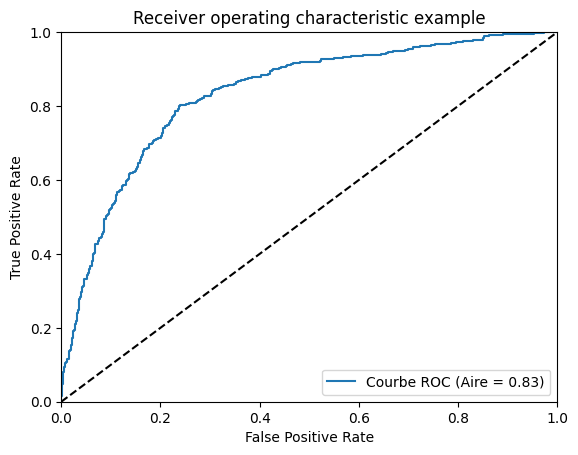

In [29]:
auc_et_roc(y_train, probas_train)

auc= 0.8229239766081871


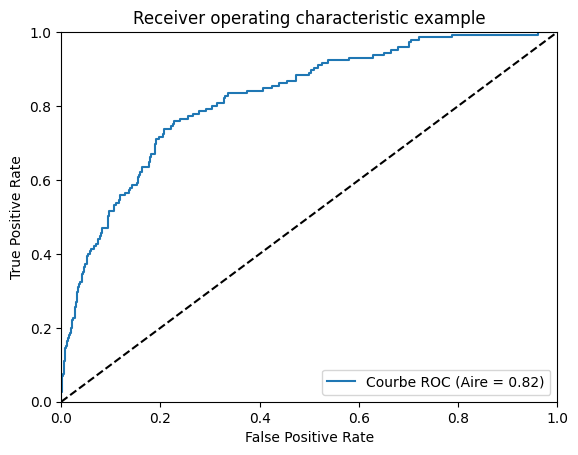

In [30]:
auc_et_roc(y_test, probas_test)

#### Sauvegarde du modèle en pickle

In [31]:
with open("../data/my_churn_model.pkl", "wb") as file:
    pickle.dump(modeleLassoCV, file)

In [32]:
# Test de réapplication
with open("../data/my_churn_model.pkl", "rb") as file:
    test_reapp_model = pickle.load(file)

In [33]:
test_reapp_model.predict_proba(X_test.head(5))

array([[0.60500839, 0.39499161],
       [0.15497113, 0.84502887],
       [0.76653555, 0.23346445],
       [0.3788085 , 0.6211915 ],
       [0.4794177 , 0.5205823 ]])

## 3.2 PARAMETRER LE MODELE RANDOMFOREST <a name="sect43" ></a>
Tester plusieurs configurations : light, medium et complexe

In [34]:
# exemple randomforest avec des rbres peu profonds
random_forest = RandomForestClassifier(                                                                       
                                       n_jobs = -1, # coeurs
                                       random_state = 42,
                                       class_weight = "balanced"
                                     )    

param = [{"n_estimators":[100,200,300], "max_depth":[3,4,5],"min_samples_split":[0.05,0.1]}]

# Grid Search : on indique le modele et la grille de param
modelerfCV = GridSearchCV (random_forest, param,cv = 4, n_jobs=-1, scoring='roc_auc', refit=True)
modelerfCV.fit(X_train,y_train)
print(modelerfCV.best_params_)
print(modelerfCV.best_score_)

{'max_depth': 5, 'min_samples_split': 0.05, 'n_estimators': 300}
0.8981412294738984


In [35]:
pd.DataFrame(modelerfCV.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
14,3.425449,0.169879,0.259446,0.053306,5,0.05,300,"{'max_depth': 5, 'min_samples_split': 0.05, 'n...",0.871296,0.901112,0.916118,0.904040,0.898141,0.016488,1
13,2.170251,0.119019,0.191834,0.057747,5,0.05,200,"{'max_depth': 5, 'min_samples_split': 0.05, 'n...",0.870423,0.901279,0.915736,0.904063,0.897875,0.016752,2
12,1.037767,0.125672,0.106713,0.028871,5,0.05,100,"{'max_depth': 5, 'min_samples_split': 0.05, 'n...",0.872828,0.899132,0.913470,0.902764,0.897048,0.014944,3
6,1.047790,0.150130,0.106119,0.024912,4,0.05,100,"{'max_depth': 4, 'min_samples_split': 0.05, 'n...",0.868042,0.897963,0.908555,0.901016,0.893894,0.015416,4
8,3.577911,0.202904,0.331150,0.064103,4,0.05,300,"{'max_depth': 4, 'min_samples_split': 0.05, 'n...",0.866509,0.899513,0.909987,0.899409,0.893855,0.016362,5
7,2.097231,0.104339,0.177240,0.022452,4,0.05,200,"{'max_depth': 4, 'min_samples_split': 0.05, 'n...",0.864270,0.899012,0.909700,0.898937,0.892980,0.017144,6
0,1.030009,0.188059,0.129275,0.033182,3,0.05,100,"{'max_depth': 3, 'min_samples_split': 0.05, 'n...",0.858446,0.893334,0.902806,0.899457,0.888511,0.017687,7
17,2.814855,0.102213,0.280308,0.061344,5,0.10,300,"{'max_depth': 5, 'min_samples_split': 0.1, 'n_...",0.850807,0.894623,0.903402,0.898063,0.886724,0.020971,8
16,1.955535,0.076754,0.181946,0.015079,5,0.10,200,"{'max_depth': 5, 'min_samples_split': 0.1, 'n_...",0.852010,0.894122,0.903474,0.896456,0.886515,0.020217,9
1,1.831572,0.111066,0.234307,0.080552,3,0.05,200,"{'max_depth': 3, 'min_samples_split': 0.05, 'n...",0.855004,0.894408,0.900945,0.894496,0.886213,0.018212,10


In [36]:
# Importance des variables Light
df=pd.DataFrame(modelerfCV.best_estimator_.feature_importances_,X_train.columns.values)
df.columns=['Importance']
df.sort_values(by='Importance',ascending=False)

,Importance
CustServ Calls,0.227052
Day Mins,0.198520
Day Charge,0.174339
Int'l Plan,0.122330
churnMoy_state,0.054080
Eve Mins,0.032266
Eve Charge,0.027175
VMail Plan,0.025278
VMail Message,0.023756
Intl Calls,0.022072


### Analyser les résultats et les performances (light)

In [37]:
# Prediction des probabilités de 1 ( array2d ) avec fonction predict_proba
probas_test = modelerfCV.predict_proba(X_test)[:,1]
probas_train = modelerfCV.predict_proba(X_train)[:,1]

In [38]:
#AUC sur train et test avec roc_auc_score
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))
# un peu de surapprentissage mais peu ce qui est normal car ce sont des arbres peu profonds

0.9353887677774317
0.8837668884855818


In [39]:
print(lift(probas_train,X_train,y_train))
print(lift(probas_test,X_test,y_test))

lift at 10 percent : 5.89
5.89
lift at 10 percent : 5.31
5.31


In [40]:
print(classification_report(y_train,modelerfCV.predict(X_train), target_names=target_names))
print(classification_report(y_test,modelerfCV.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

     Fidèles       0.97      0.89      0.93      1995
    Churners       0.56      0.86      0.68       338

    accuracy                           0.88      2333
   macro avg       0.77      0.87      0.80      2333
weighted avg       0.91      0.88      0.89      2333

              precision    recall  f1-score   support

     Fidèles       0.97      0.85      0.91       855
    Churners       0.49      0.85      0.62       145

    accuracy                           0.85      1000
   macro avg       0.73      0.85      0.76      1000
weighted avg       0.90      0.85      0.86      1000



In [41]:
# AJOUTE LES RESULTATS
model='Score Random Forest'
# métriques (liste de dictionnaires)
metriques.append([{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}])
metriques

lift at 5 percent : 6.07
lift at 10 percent : 5.31


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.884,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.31)}]]

## 3.4 PARAMETRER LE MODELE GRADIENT BOOSTING MACHINE <a name="sect44" ></a>


In [42]:
from sklearn.ensemble import GradientBoostingClassifier

In [43]:
gbclassifier =GradientBoostingClassifier(
                                       random_state=42)

param = [{"n_estimators":[100,200,300], "max_depth":[2,3],"subsample":[0.9,1.0], "learning_rate":[0.001,0.01,0.05]}]

# Grid Search : on indique le modele et la grille de param
modelegbmCV = GridSearchCV (gbclassifier, param, cv = 4,n_jobs=-1, scoring='roc_auc', refit=True)
modelegbmCV.fit(X_train,y_train)
print(modelegbmCV.best_params_)
print(modelegbmCV.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}
0.9232061478767328


In [44]:
pd.DataFrame(modelegbmCV.cv_results_).sort_values(['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
32,5.647782,0.261734,0.028623,0.011122,0.050,3,200,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.901898,0.918170,0.939140,0.933617,0.923206,0.014506,1
34,8.845023,0.079545,0.042605,0.013623,0.050,3,300,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.902346,0.917382,0.937637,0.934467,0.922958,0.014176,2
35,8.707187,0.260423,0.028566,0.003601,0.050,3,300,1.0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.901615,0.916190,0.936874,0.932412,0.921773,0.013953,3
33,5.807158,0.356927,0.033659,0.002261,0.050,3,200,1.0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.896216,0.917764,0.938711,0.932530,0.921305,0.016363,4
30,2.942662,0.137995,0.030425,0.007908,0.050,3,100,0.9,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.895709,0.914937,0.942051,0.926388,0.919771,0.016901,5
31,3.002604,0.160126,0.021854,0.004891,0.050,3,100,1.0,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.891689,0.917299,0.939904,0.921415,0.917577,0.017201,6
28,7.254312,1.347615,0.029362,0.008279,0.050,2,300,0.9,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.895131,0.914162,0.931530,0.926412,0.916809,0.014016,7
22,8.719048,0.191486,0.030479,0.005692,0.010,3,300,0.9,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.890404,0.917084,0.937613,0.920021,0.916281,0.016877,8
23,9.011129,0.159044,0.035524,0.005689,0.010,3,300,1.0,"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",0.892668,0.917669,0.932222,0.916466,0.914756,0.014181,9
29,6.377934,0.199321,0.028296,0.003090,0.050,2,300,1.0,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.893858,0.913040,0.932031,0.920080,0.914752,0.013842,10


Analyse du nb iterations optimal en affichant la fonction de perte sur le test

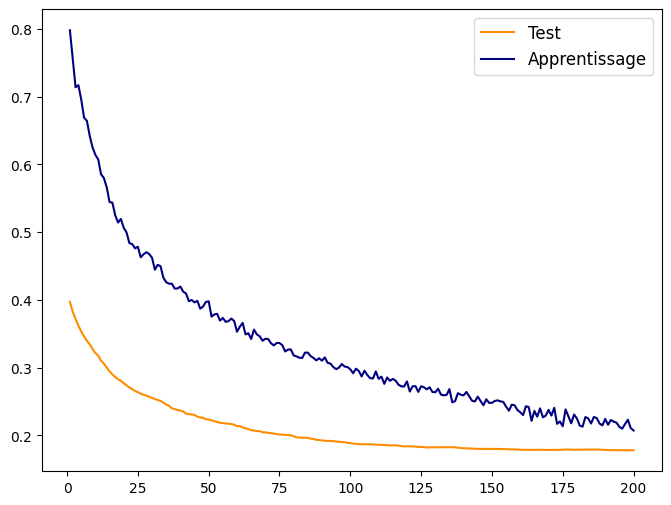

In [45]:
from sklearn.metrics import log_loss

niter = modelegbmCV.best_estimator_.n_estimators
iter = np.arange(niter) + 1
test_deviance = np.zeros((niter,), dtype=np.float64)

# staged_predict_proba donne les probabilités à chaque itération
for i, y_pred_proba in enumerate(modelegbmCV.best_estimator_.staged_predict_proba(X_test)):
    test_deviance[i] = log_loss(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(iter, test_deviance, label='Test', color='darkorange')
plt.plot(iter, modelegbmCV.best_estimator_.train_score_, label='Apprentissage', color='navy')
plt.legend(loc="upper right", fontsize=12)
plt.show()


In [46]:
# Algo avc les mêmes params sauf le nombre d'estimators que l'on met à 150 
# car nous remarquons qu'il n'y pas d'amélioration sur le test set après 150 itérations.
gbt_Rand = GradientBoostingClassifier(**modelegbmCV.best_params_)
gbt_Rand.n_estimators = 150
# Apprentissage du modele
gbt_Rand.fit(X_train,y_train)
gbt_Rand

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

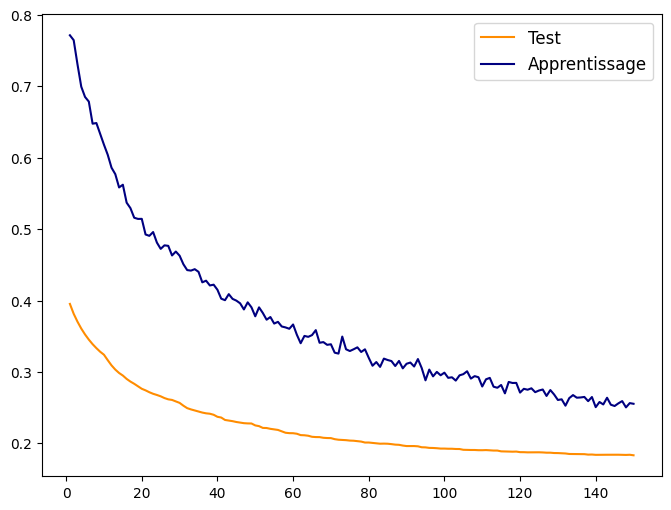

In [47]:
niter=gbt_Rand.n_estimators
iter = np.arange(niter) + 1
test_deviance = np.zeros((niter,), dtype=np.float64)
# staged_decision_functio : décision fonction à chaque iteration
for i, y_pred_proba in enumerate(gbt_Rand.staged_predict_proba(X_test)):
    test_deviance[i] = log_loss(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
# Erreur sur le test (evolution deviance)
plt.plot(iter,test_deviance,label='Test',color='darkorange')
        # min vers 100 
# Erreur sur apprentissage (evolution deviance)
plt.plot(iter,gbt_Rand.train_score_,label='Apprentissage',color='navy')    
# Diminution de l'erreur rapport modele precedant (par rapport au oob)
#plt.plot(iter,gbt_noRand05.oob_improvement_)
plt.legend(loc="upper right", fontsize=12)

### Analyser les résultats et les performances (meilleur modèle issue de la recherche d'hyperparamètres) 

In [48]:
# Prediction des probabilités de 1 , array2d
probas_test = modelegbmCV.predict_proba(X_test)[:,1]
probas_train = modelegbmCV.predict_proba(X_train)[:,1]


In [49]:
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))


0.9795272204179086
0.9058277878604559


In [50]:
print(classification_report(y_train,modelegbmCV.predict(X_train), target_names=target_names))
print(classification_report(y_test,modelegbmCV.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

     Fidèles       0.97      1.00      0.99      1995
    Churners       1.00      0.84      0.91       338

    accuracy                           0.98      2333
   macro avg       0.99      0.92      0.95      2333
weighted avg       0.98      0.98      0.98      2333

              precision    recall  f1-score   support

     Fidèles       0.96      0.99      0.97       855
    Churners       0.91      0.74      0.82       145

    accuracy                           0.95      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.95      0.95      0.95      1000

              precision    recall  f1-score   support

     Fidèles       0.96      0.99      0.97       855
    Churners       0.91      0.74      0.82       145

    accuracy                           0.95      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.95      0.95      0.95      1000



In [51]:
# AJOUTE LES RESULTATS
model='best gbm from grid search'
# métriques (liste de dictionnaires)
metriques.append([{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}])
metriques
# conclusion  le modele RF est plus predictif mais moins confiance dans sa capacité à etre robuste à moyen terme


lift at 5 percent : 6.9
lift at 10 percent : 6.48


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.884,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.31)}],
 [{'model': 'best gbm from grid search',
   'AUC_test': 0.906,
   'lift at 5': np.float64(6.9),
   'lift at 10': np.float64(6.48)}]]

In [52]:
# Prediction des probabilités de 1 , array2d
probas_test = gbt_Rand.predict_proba(X_test)[:,1]
probas_train = gbt_Rand.predict_proba(X_train)[:,1]


In [53]:
print(roc_auc_score(y_train,probas_train))
print(roc_auc_score(y_test,probas_test))


0.9693101095935104
0.9051824964710626
0.9051824964710626


In [54]:
print(classification_report(y_train,gbt_Rand.predict(X_train), target_names=target_names))
print(classification_report(y_test,gbt_Rand.predict(X_test), target_names=target_names))

              precision    recall  f1-score   support

     Fidèles       0.97      1.00      0.99      1995
    Churners       0.99      0.84      0.91       338

    accuracy                           0.98      2333
   macro avg       0.98      0.92      0.95      2333
weighted avg       0.98      0.98      0.97      2333

              precision    recall  f1-score   support

     Fidèles       0.96      0.99      0.97       855
    Churners       0.92      0.74      0.82       145

    accuracy                           0.95      1000
   macro avg       0.94      0.87      0.90      1000
weighted avg       0.95      0.95      0.95      1000



In [55]:
# AJOUTE LES RESULTATS
model='gbm light'
# métriques (liste de dictionnaires)
metriques.append([{'model':model,'AUC_test':round(roc_auc_score(y_test,probas_test),3),'lift at 5':lift(probas_test,X_test,y_test,p=5),'lift at 10':lift(probas_test,X_test,y_test,p=10)}])
metriques
# conclusion  le modele RF est plus predictif mais moins confiance dans sa capacité à etre robuste à moyen terme


lift at 5 percent : 6.76
lift at 10 percent : 6.48


[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.884,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.31)}],
 [{'model': 'best gbm from grid search',
   'AUC_test': 0.906,
   'lift at 5': np.float64(6.9),
   'lift at 10': np.float64(6.48)}],
 [{'model': 'gbm light',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.76),
   'lift at 10': np.float64(6.48)}]]

# 4. Comparaison et conclusion 

In [56]:
metriques

[{'model': 'Score Lasso',
  'AUC_test': 0.823,
  'lift at 5': np.float64(4.28),
  'lift at 10': np.float64(3.86)},
 [{'model': 'Score Random Forest',
   'AUC_test': 0.884,
   'lift at 5': np.float64(6.07),
   'lift at 10': np.float64(5.31)}],
 [{'model': 'best gbm from grid search',
   'AUC_test': 0.906,
   'lift at 5': np.float64(6.9),
   'lift at 10': np.float64(6.48)}],
 [{'model': 'gbm light',
   'AUC_test': 0.905,
   'lift at 5': np.float64(6.76),
   'lift at 10': np.float64(6.48)}]]